<h1 align="center"> Image Captioning </h1>

В этом ноутбуке мы обучим сеть составлять подписи к изображениям.

![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные

In [ ]:
# Скачать датасет можно по ссылке https://drive.google.com/file/d/1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO/view?usp=sharing

In [ ]:
%%time
import numpy as np
import json

img_codes = np.load("data/image_codes.npy")
captions = json.load(open('data/captions_tokenized.json'))

CPU times: total: 516 ms
Wall time: 514 ms



Чтобы сэкономить время, я взял уже преобразованные изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

Весь процесс занимает от одного дня на CPU до примерно 10 минут на трёх GPU Tesla M40.


In [64]:
captions = captions
img_codes = img_codes

print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [65]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


Мы не хотим, чтобы сеть на каждом шаге предсказывала вероятности для миллиона слов, поэтому нужно немного сократить словарь.

In [66]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for image_i in range(len(captions)):
    for caption_i in range(len(captions[image_i])):
        word_counts.update(captions[image_i][caption_i])


word_counts.most_common(10)

[('a', 978125),
 ('#START#', 591435),
 ('#END#', 591435),
 ('.', 444651),
 ('on', 215537),
 ('of', 203940),
 ('the', 197668),
 ('in', 183933),
 ('with', 154705),
 ('and', 140709)]

In [67]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [68]:
import numpy as np


eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [69]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети

Как уже упоминалось, мы создадим RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения мы будем использовать уже готовые вектора-признаков, а сеть Inception добавим на этапе инференса.


In [70]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [ ]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        self.emb = nn.Embedding(n_tokens, emb_size)

        self.lstm = nn.LSTM(emb_size, lstm_units, batch_first=True)

        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        captions_emb = self.emb(captions_ix)

        lstm_out = self.lstm(captions_emb, (initial_cell[None], initial_hid[None]))

        logits = self.logits(lstm_out[0])

        return logits

In [72]:
network = CaptionNet(n_tokens)

In [73]:
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [ ]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """

    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    logits_for_next = network.forward(image_vectors, captions_ix_inp)

    loss = F.cross_entropy(
        logits_for_next.view(-1, logits_for_next.shape[-1]),
        captions_ix_next.view(-1),
        ignore_index=pad_ix
    )

    loss = loss.unsqueeze(0)

    return loss

In [75]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([1]), 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'


Добавим ~~adam~~ наш любимый оптимизатор для обучения)))

In [76]:
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)

### 3. Обучение

* Сначала реализуем генератор батчей.
* Затем обучим сеть как обычно.

In [78]:
from sklearn.model_selection import train_test_split
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [ ]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    batch_images = img_codes[random_image_ix]

    captions_for_batch_images = [captions[i] for i in random_image_ix]

    batch_captions = list(map(choice,captions_for_batch_images))

    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [82]:
generate_batch(img_codes,captions,3)

(tensor([[0.2499, 0.2107, 0.5380,  ..., 0.2144, 0.9516, 0.5656],
         [0.2289, 0.0304, 0.0732,  ..., 0.0000, 0.5471, 0.3294],
         [0.0179, 0.0865, 0.2862,  ..., 0.3493, 0.6932, 0.2080]]),
 tensor([[   1,   24,  278,  693,   41,   94,    6,  159,   14,   24,  373,  357,
            15,   24,  184,    2],
         [   1,  262,  896,   35,   45,  902,    6,  159,   14,  472, 1125,   45,
           165,    2,    3,    3],
         [   1,   24,  169,   14, 4356,   58, 1332,  123, 1040,  123,  141, 1647,
            15,  472,    2,    3]]))

Обучим модель на мини-батчах, как обычно. Периодически проверяя качество на валидационном наборе.

#### **Советы из интернета**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [83]:
batch_size = 32  # adjust me
n_epochs = 50  # adjust me
n_batches_per_epoch = 32  # adjust me
n_validation_batches = 5  # how many batches are used for validation after each epoch

In [ ]:
from tqdm import tqdm

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):

        loss_t = compute_loss(network, *generate_batch(train_img_codes, train_captions, batch_size))


        optimizer.zero_grad()
        loss_t.backward()
        optimizer.step()

        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        loss_t = compute_loss(network, *generate_batch(val_img_codes, val_captions, batch_size))
        val_loss += loss_t.item()
    val_loss /= n_validation_batches

    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

print("Finished!")

100%|██████████| 32/32 [00:03<00:00,  9.45it/s]



Epoch: 0, train loss: 6.656480073928833, val loss: 5.191246414184571


100%|██████████| 32/32 [00:03<00:00,  9.97it/s]



Epoch: 1, train loss: 5.014540821313858, val loss: 4.881320667266846


100%|██████████| 32/32 [00:03<00:00,  8.58it/s]


...


Epoch: 47, train loss: 3.0901012048125267, val loss: 3.185897779464722


100%|██████████| 32/32 [00:04<00:00,  7.13it/s]



Epoch: 48, train loss: 3.1134069114923477, val loss: 3.2315839767456054


100%|██████████| 32/32 [00:04<00:00,  7.12it/s]



Epoch: 49, train loss: 3.1381388679146767, val loss: 2.9996569633483885
Finished!


### 4. Применяем обученную модель

Теперь загрузим предобученнную Inceprion модель и посмотрим, на что способна наша модель.


In [93]:
from beheaded_inception3 import beheaded_inception_v3
inception = beheaded_inception_v3().train(False)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/inception_v3_google-1a9a5a14.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\inception_v3_google-1a9a5a14.pth


100%|██████████| 104M/104M [01:44<00:00, 1.04MB/s] 


#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [94]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        vectors_8x8, vectors_neck, logits = inception(image[None])
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [103]:
from matplotlib import pyplot as plt
import cv2
%matplotlib inline

#sample image
!wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = cv2.resize(img, (299, 299)).astype('float32') / 255.

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


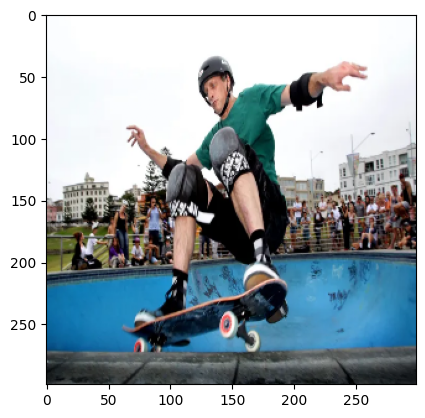

In [104]:
plt.imshow(img)

In [105]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man is riding a skateboard down a street .
a man riding a skateboard in a park .
a man in a suit riding a skateboard .
a man in a suit and a skateboard in a suit .
a man in a suit and a skateboard .
a man in a suit and a skateboard on a skateboard .
a man on a skateboard in a park bench .
a man riding a skateboard on a skateboard .
a man in a suit and a skateboard on a skateboard .
a man in a suit and a man on a skateboard .


"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


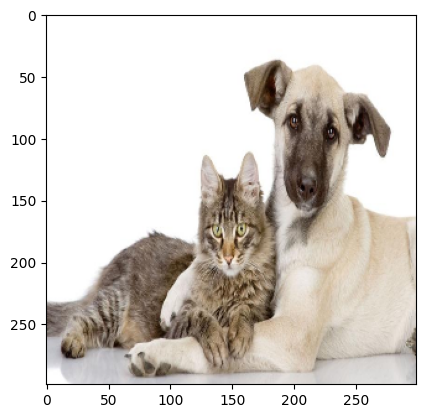

a cat is sitting on a bed in a room .
a dog sitting on a bed with a dog .
a cat laying on a bed with a dog .
a cat is laying on a bed in a room .
a dog laying down in front of a desk .
a dog sitting on a bed in a room .
a dog laying on a bed with a dog in the background .
a dog sitting on a bed with a dog .
a dog sitting on a bed in a room .
a dog sitting on a bed with a black and white dog .


In [ ]:
img = plt.imread('data/img_2.jpeg')
img = cv2.resize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

### 5. Demo
##### **Найдем как минимум 10 изображений для теста.**

* Сначала проверим работу модели на простых изображениях, прежде чем переходить к более сложным.

* В нашем наборе должны быть примеры как удачных, так и неудачных подписей

* Используем фотографии, а не анимацию, 3D или рисунки — иначе придётся переобучать CNN на аниме.

* Обратим внимание на соотношение сторон изображений.

In [124]:
def analyze_picture(image_name):
    img = plt.imread(f'data/{image_name}')
    img = cv2.resize(img, (299, 299)).astype('float32') / 255.

    plt.imshow(img)
    plt.show()

    for i in range(10):
        print(' '.join(generate_caption(img, t=5.)[1:-1]))


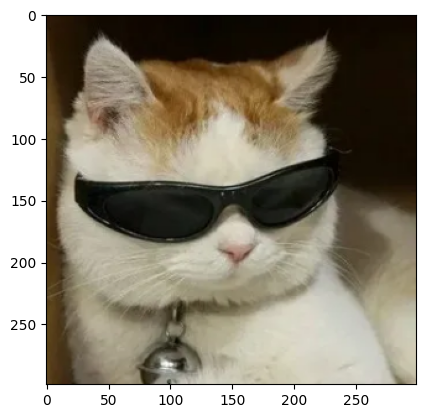

a cat is sitting on a bench in a room .
a dog is sitting on a bench in a room .
a cat is sitting on a bench in a room .
a man sitting on a bench in a room .
a dog is sitting on a bench in a room .
a dog is sitting on a bench with a dog .
a cat is sitting on a bed with a dog .
a dog is sitting on a bench in a room .
a cat is sitting on a bed in a room .
a cat is sitting on a bench in a room .


In [ ]:
analyze_picture('my_1.jpeg')

Про очки он видно не знает ничего(

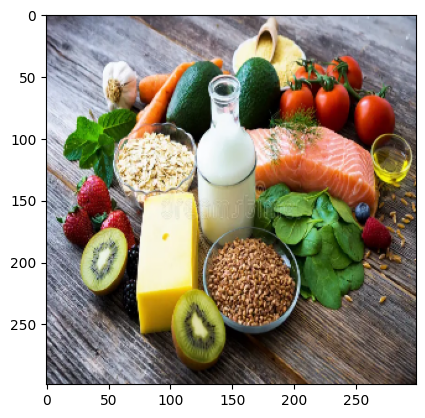

a bowl of food with a bowl of food .
a plate of food with a bowl of food .
a bowl of food with a bowl of food .
a plate of food with a bowl of food .
a bowl of food on a plate with a bowl of food .
a plate of food with a bowl of food .
a bowl of food with a bowl of food .
a plate with a bowl of food on it .
a plate with a bowl of food and a bowl of food .
a plate of food with a bowl of food .


In [125]:
analyze_picture('my_2.jpeg')

Отдельные части тоже не особо, про овощи не высказалась ни разу, сколько не переобучай (на этой картинке)

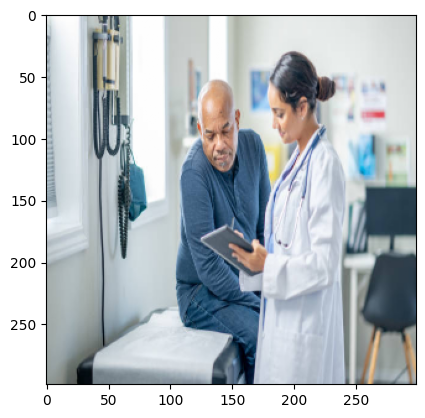

a man sitting in a kitchen with a laptop computer .
a man standing in a room with a remote .
a man sitting in a kitchen with a laptop and a tie .
a man in a suit and tie in a suit .
a man in a suit and tie on a table
a man is sitting in a kitchen with a tie .
a man sitting in a kitchen with a laptop and a tie .
a man standing in front of a table with a remote .
a man in a suit and tie in a suit .
a man sitting in a kitchen with a laptop computer .


In [127]:
analyze_picture('my_3.jpg')

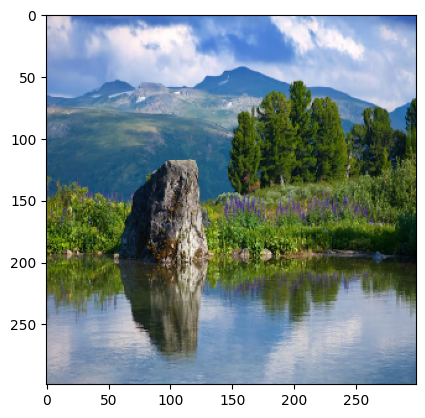

a large white photo of a large white and white photo of a large building .
a group of people riding a wave in the ocean .
a large white bird standing in the grass .
a large white and white photo of a building .
a large white photo of a large tree .
a group of people walking down a hill .
a large white and white photo of a large building .
a large white photo of a tree in the air .
a group of people riding a wave in the ocean .
a large white and white photo of a tree .


In [131]:
analyze_picture('my_4.jpg')

Просто с пейзажи даются ему не просто, если постараться уменьшить лосс, то модель переобучается и видит везде пиццу и фризби, а сейчас текст бывает не совсем связным. По крайней мере, говорит про горы, деревья и воду

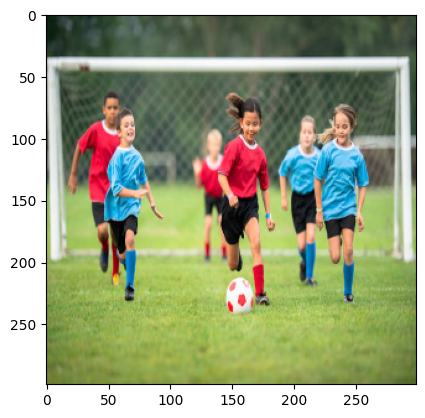

a man standing in a field with a baseball bat .
a man is standing in a field with a baseball bat .
a man is playing soccer with a frisbee .
a man is standing in the air with a frisbee .
a group of people playing soccer in a field .
a man standing in the air with a baseball bat .
a man standing in a field with a baseball bat .
a man standing in front of a baseball game .
a man in a field with a baseball bat .
a group of people playing soccer in the air .


In [132]:
analyze_picture('my_5.jpg')

Мое любимое фрисби! Спорт дается получше, людей видит так же очень неплохо

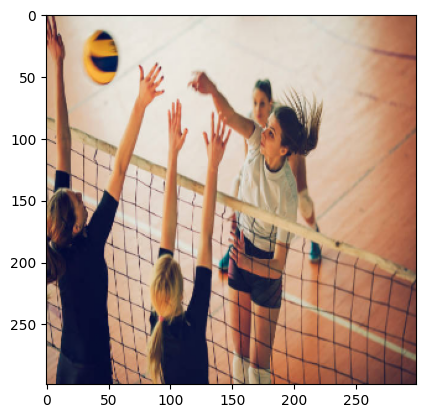

a group of people are playing soccer in the grass .
a group of people playing soccer in a field .
a group of people playing soccer with a frisbee .
a group of people standing in the grass with a frisbee .
a group of people standing in the grass with a frisbee .
a group of people are playing soccer in the grass .
a group of people playing soccer on a field .
a group of people standing in a field with a frisbee .
a group of people playing soccer in the grass .
a group of people standing in a field with a baseball .


In [133]:
analyze_picture('my_6.jpg')

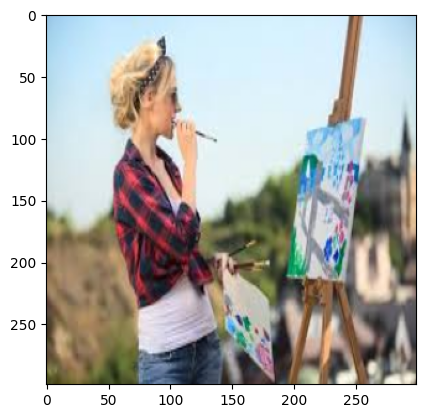

a man is standing in front of a man in a field .
a man holding a frisbee in a field .
a man is standing in front of a man in a field .
a man in a suit and a woman standing in a field .
a man holding a frisbee in the middle of a man .
a man in a suit and a woman in a suit .
a man in a suit and a woman standing in front of a building .
a man is walking down a street in front of a building .
a man is standing in a field with a frisbee .
a man is standing in front of a man in a field .


In [134]:
analyze_picture('my_7.jpeg')

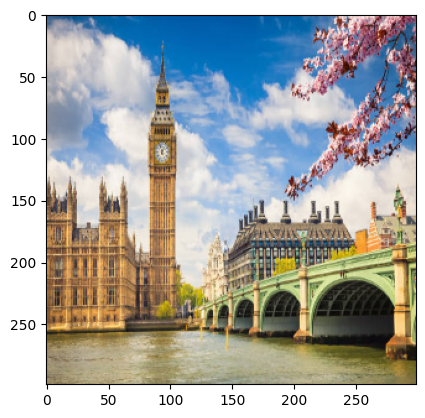

a large clock tower with a clock on it
a large clock tower with a clock on it .
a large building with a clock tower on the side of a building .
a building with a clock tower in the background .
a building with a clock tower on the side of a building .
a building with a clock tower in the background .
a clock tower is in the air in the background .
a building with a clock tower in the background .
a building with a clock tower in the background .
a clock tower in a parking lot .


In [136]:
analyze_picture('my_8.jpg')

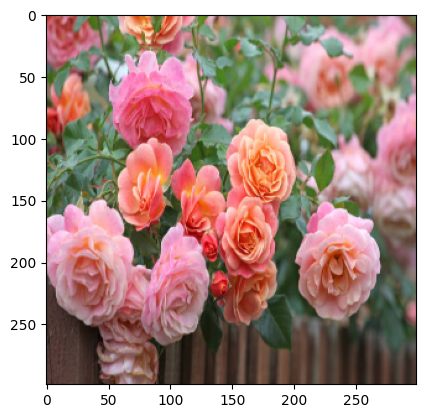

a bunch of flowers are sitting on a table .
a large white vase of flowers in a vase .
a white vase with a vase of flowers in it .
a bunch of flowers are sitting on a table .
a large white vase of food and a vase with a clock on it .
a white vase of food on a table with a clock .
a large white vase of flowers on a table .
a large white vase of flowers on a table .
a white vase of food with a vase on it .
a large white vase with a large vase of flowers .


In [137]:
analyze_picture('my_9.jpg')

О существовании цветов он знает, уже неплохо. Похоже цветы в вазе ему нравятся намного больше

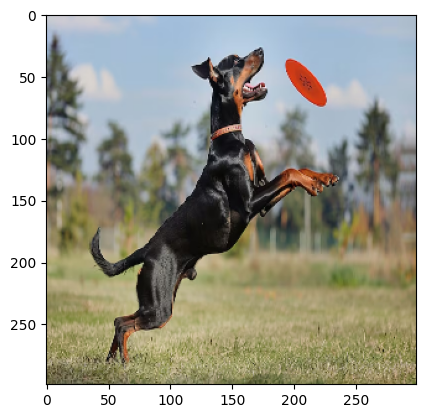

a man riding a skateboard down a street .
a man riding a skateboard down a street .
a man riding a skateboard in a parking lot .
a man riding a skateboard down a street .
a man riding a skateboard down a street .
a man riding a skateboard down a road .
a man riding a skateboard down a road .
a man riding a skateboard down a street .
a man riding a skateboard down a street .
a man is riding a skateboard in a field .


In [140]:
analyze_picture('my_10.jpg')

Это должен был быть ее звездный час! Возможно картинка не самая удачная?

То есть он видит фрисби везде, кроме картинок с фрисби, забавно

В итоге, я попытался подобрать максимально разнообразные картинки, лучше всего сеть видит людей, вполне неплохо справляется с часами, цветами и животными. Хуже всего с отдельными овощами и круглыми объектами, у меня она в большей части случаев видела в них пиццу или фрисби

Видимо этой игры не было при обучении или ее было очень мало